In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load your local dataset
df = pd.read_csv('Titanic-Dataset.csv')

# 1. Fill missing Age with the mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# 2. Drop irrelevant columns (Cabin is mostly missing, Name/Ticket are unique strings)
df.drop(columns=['Cabin', 'Name', 'Ticket'], inplace=True)

# 3. Create 'FamilySize' (SibSp + Parch)
df['FamilySize'] = df['SibSp'] + df['Parch']

In [9]:
# A. Survival rate by Age Group
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teenager', 'Adult', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_survival = df.groupby('AgeGroup',observed=False)['Survived'].mean()

# B. Survival rate by Embarkation Port (C = Cherbourg, Q = Queenstown, S = Southampton)
port_survival = df.groupby('Embarked')['Survived'].mean()

# C. Survival rate by Family size
family_survival = df.groupby('FamilySize')['Survived'].mean()

print("--- Survival Insights ---")
print(f"By Age Group:\n{age_survival}\n")
print(f"By Port:\n{port_survival}\n")
print(f"By Family Size:\n{family_survival}")

--- Survival Insights ---
By Age Group:
AgeGroup
Child       0.579710
Teenager    0.428571
Adult       0.365753
Senior      0.227273
Name: Survived, dtype: float64

By Port:
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

By Family Size:
FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


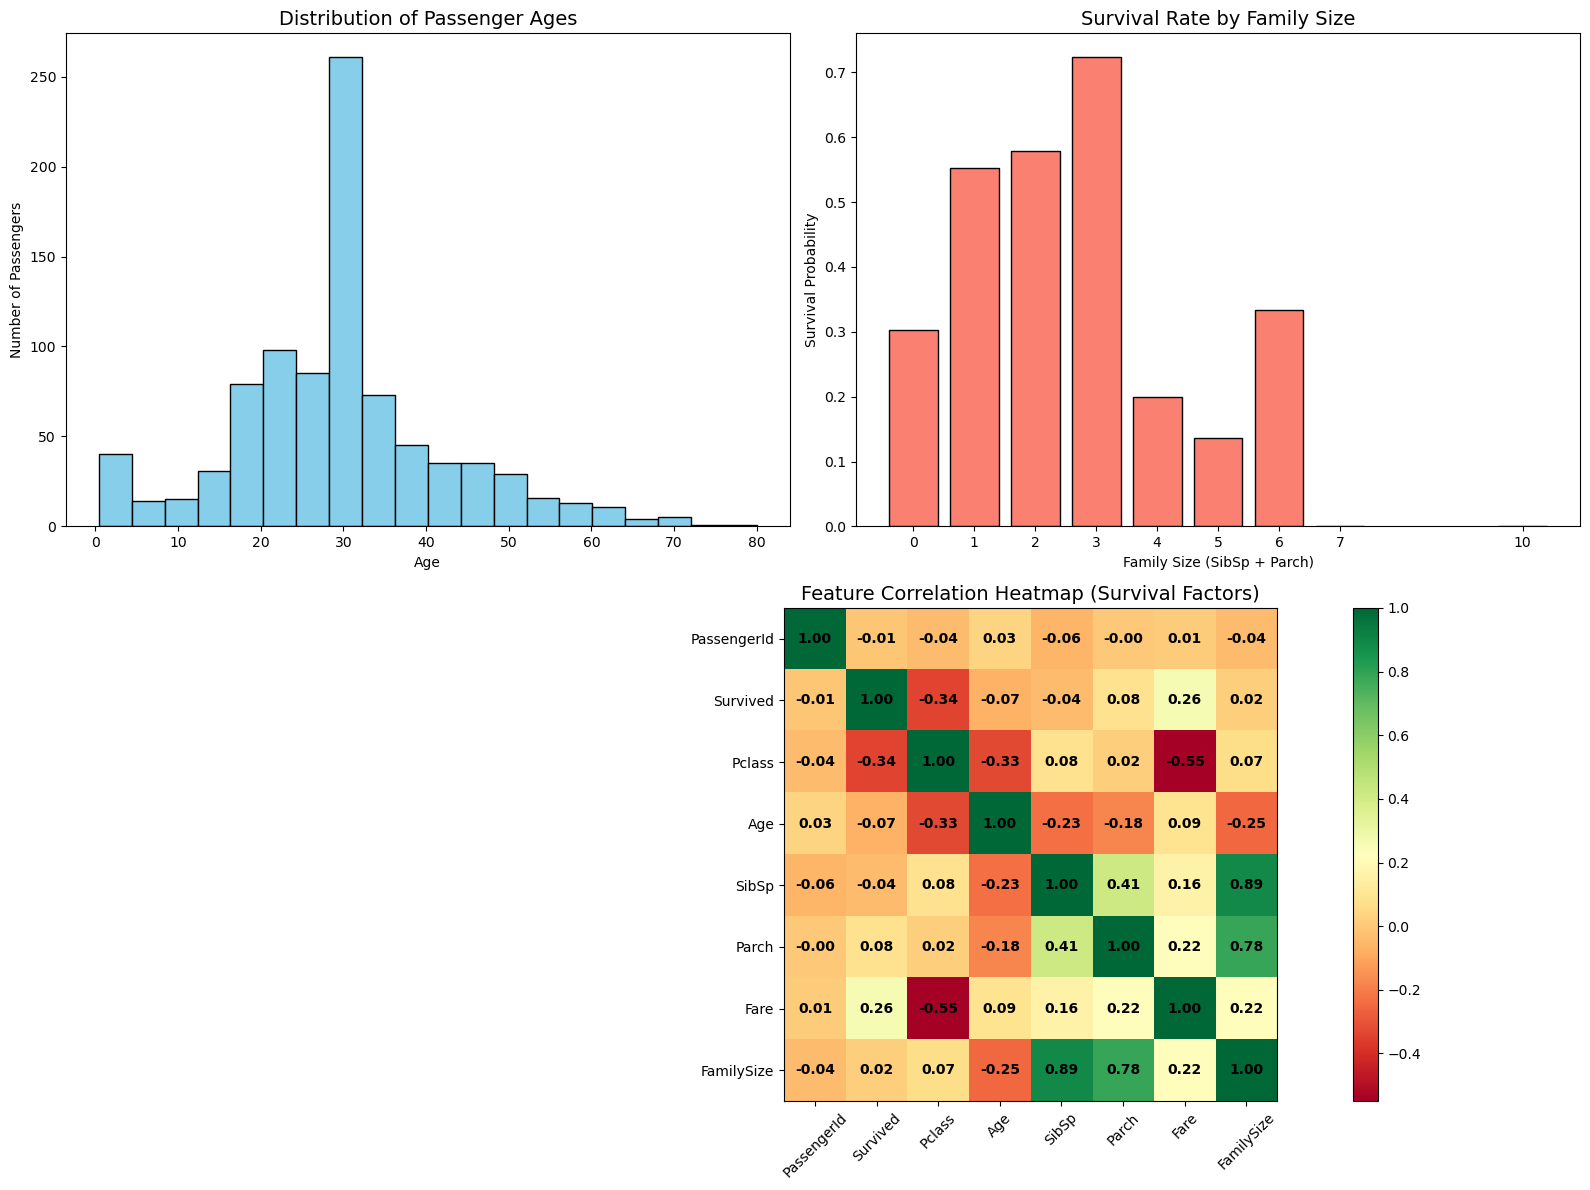

In [10]:
# Set the plot style and size
plt.figure(figsize=(16, 12))

# --- Plot 1: Age Distribution (Histogram) ---
plt.subplot(2, 2, 1)
plt.hist(df['Age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Passenger Ages', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

# --- Plot 2: Survival by Family Size (Bar Plot) ---
plt.subplot(2, 2, 2)
plt.bar(family_survival.index, family_survival.values, color='salmon', edgecolor='black')
plt.title('Survival Rate by Family Size', fontsize=14)
plt.xlabel('Family Size (SibSp + Parch)')
plt.ylabel('Survival Probability')
plt.xticks(family_survival.index)

# --- Plot 3: Heatmap of Correlations ---
plt.subplot(2, 1, 2)
# Select only numeric columns for correlation
corr = df.select_dtypes(include=[np.number]).corr()
im = plt.imshow(corr, cmap='RdYlGn', interpolation='nearest')

# Add Colorbar and Labels
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Annotate each cell with the correlation value
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontweight='bold')

plt.title('Feature Correlation Heatmap (Survival Factors)', fontsize=14)

plt.tight_layout()
plt.show()